# 07 — Task 2 test-set submission

Produces `submission/task2_predictions.csv`. **Nothing is refit.** The best approach is chosen on validation mean NME by reading `results/*_metrics.json`, then loaded as-is from `models/`.

Binding constraints (`AML_project_plan_revised.md` §4.9, §7, §8):
1. Test order is preserved end-to-end — no sort, no dedupe, no filter (Tripwire §8 #1).
2. Predictions are emitted in **original image resolution**, with the scaling factor tracked per image (Tripwire §8 #2).
3. Output shape is `(n_test_images, n_points, 2)` flattened to one row per image with 10 columns `x0, y0, …, x4, y4` (§4.9).
4. Lecture-taught only.

In [1]:
import csv
import json
import sys
from pathlib import Path

import cv2
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from skimage.feature import hog as skhog

NB_DIR = Path.cwd()
sys.path.insert(0, str(NB_DIR / 'src'))
from preprocess_img import load_data, preprocess_image, DEFAULT_CONFIG  # noqa: E402
from landmarks import nme  # noqa: E402
from cnn import FaceCNN, predict_landmarks  # noqa: E402

MODELS_DIR = NB_DIR / 'models'
RESULTS_DIR = NB_DIR / 'results'
FIG_DIR = NB_DIR / 'figures'
SUB_DIR = NB_DIR / 'submission'
for d in (FIG_DIR, SUB_DIR):
    d.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device =', device)

device = cpu


## 1. Choose best model

Collect val mean NME from every `results/*_metrics.json` produced by 02–05 and pick the lowest. CNN metrics live under two sub-keys (`cnn_aug`, `cnn_noaug`) — both are considered. The choice is recorded in `models/BEST_MODEL_T2.txt` for downstream reproducibility.

In [2]:
candidates = []  # (label, val_mean_nme, source_file)

def _add(label, val, src):
    if isinstance(val, (int, float)) and not np.isnan(val):
        candidates.append((label, float(val), str(src)))

for path in sorted(RESULTS_DIR.glob('*_metrics.json')):
    with open(path) as f:
        m = json.load(f)
    name = path.stem
    # Approach-1 file stores {'hog_ridge': {mean_nme}, 'raw_ridge': {...}, ...}
    if name == 'hog_linreg_metrics':
        _add('hog_ridge', m.get('hog_ridge', {}).get('mean_nme'), path)
        _add('raw_ridge', m.get('raw_ridge', {}).get('mean_nme'), path)
    elif name == 'cascaded_metrics':
        _add('cascaded', m.get('mean_nme'), path)
    elif name == 'cnn_metrics':
        _add('cnn_aug',   m.get('cnn_aug',   {}).get('mean_nme'), path)
        _add('cnn_noaug', m.get('cnn_noaug', {}).get('mean_nme'), path)
    elif name == 'baseline_metrics':
        _add('mean_face', m.get('mean_nme'), path)
    else:
        # Generic fallback for any other metrics file with a top-level 'mean_nme'.
        _add(name.replace('_metrics', ''), m.get('mean_nme'), path)

candidates.sort(key=lambda r: r[1])
print('Approach val mean NMEs (lower is better):')
for lab, v, _src in candidates:
    print(f'  {lab:<14s}  {v:.4f}')

BEST_LABEL, BEST_NME, _ = candidates[0]
print(f'\n→ chosen model: {BEST_LABEL}  (val mean NME = {BEST_NME:.4f})')

(MODELS_DIR / 'BEST_MODEL_T2.txt').write_text(f'{BEST_LABEL}\n{BEST_NME:.6f}\n')
print('saved', MODELS_DIR / 'BEST_MODEL_T2.txt')

Approach val mean NMEs (lower is better):
  cascaded        0.0510
  hog_ridge       0.0564
  raw_ridge       0.0745
  cnn_noaug       0.0758
  cnn_aug         0.0832
  mean_face       0.1246

→ chosen model: cascaded  (val mean NME = 0.0510)
saved /Users/joebaldwin/Desktop/2nd-year/Second-Semester/Introduction to Applied Machine Learning/AMLAssignment/task2_cv/models/BEST_MODEL_T2.txt


## 2. Load test data — order preserved

`preprocess_img.load_data()` reads the train/test arrays via `data/data_layout.json`. We use the same loader the other notebooks use so paths and array keys can't drift. **No sorting / deduping / filtering** — the original test row order must reach the CSV unchanged (Tripwire §8 #1).

In [3]:
data = load_data()
test_images = data['test_images']
layout = data['layout']

N_test = int(test_images.shape[0])
print(f'N_test = {N_test}')
print(f'test array shape = {test_images.shape}  dtype = {test_images.dtype}')

# Per-image original (H, W). Even if the array is rectangular and uniform, this is the
# safest possible scale-back: it handles a ragged future test set without code changes.
orig_HW = np.zeros((N_test, 2), dtype=np.int32)
for i in range(N_test):
    orig_HW[i] = test_images[i].shape[:2]

uniform = bool(np.all(orig_HW == orig_HW[0]))
H_out, W_out = DEFAULT_CONFIG['out_size']
if uniform:
    H0, W0 = int(orig_HW[0, 0]), int(orig_HW[0, 1])
    print(f'uniform original size: ({H0}, {W0})  →  sx = {W0/W_out:.4f}, sy = {H0/H_out:.4f}')
else:
    print('original sizes vary per image — per-image scale factors will be applied.')
    print(f'  H range = [{int(orig_HW[:,0].min())}, {int(orig_HW[:,0].max())}]')
    print(f'  W range = [{int(orig_HW[:,1].min())}, {int(orig_HW[:,1].max())}]')

expected = int(layout.get('test', {}).get('count', N_test))
assert N_test == expected, f'test row count {N_test} != expected {expected}'
print('test count matches data_layout.json')

N_test = 554
test array shape = (554, 256, 256, 3)  dtype = uint8
uniform original size: (256, 256)  →  sx = 4.0000, sy = 4.0000
test count matches data_layout.json


## 3. Preprocess to 64×64

Exactly the training-time pipeline: grayscale → resize → normalise to [0, 1] (`DEFAULT_CONFIG`). The resize function returns `landmarks=None` for the test set as flagged in the brief — we keep only the image.

In [4]:
X_test_64 = np.zeros((N_test, H_out, W_out), dtype=np.float32)
for i in range(N_test):
    img64, _none = preprocess_image(test_images[i], None, DEFAULT_CONFIG)
    X_test_64[i] = img64

print(f'X_test_64: {X_test_64.shape}  range=[{X_test_64.min():.3f}, {X_test_64.max():.3f}]  dtype={X_test_64.dtype}')
assert X_test_64.shape == (N_test, H_out, W_out)

X_test_64: (554, 64, 64)  range=[0.000, 1.000]  dtype=float32


## 4. Predict in 64×64 coordinates

Branch on the chosen approach. All branches return a `(N_test, 5, 2)` array of float coordinates in the 64×64 frame.

In [5]:
def predict_hog_ridge(X):
    bundle = joblib.load(MODELS_DIR / 'hog_ridge.joblib')
    feats = np.stack([skhog(X[i], **bundle['hog_kw']) for i in range(X.shape[0])])
    return bundle['model'].predict(feats).reshape(-1, 5, 2).astype(np.float32)


def _extract_patch_hog(img, point, patch_size, hog_kw):
    H, W = img.shape
    half = patch_size // 2
    cx = int(round(float(point[0]))); cy = int(round(float(point[1])))
    x0, x1 = cx - half, cx - half + patch_size
    y0, y1 = cy - half, cy - half + patch_size
    pad_left = max(0, -x0); pad_top = max(0, -y0)
    pad_right = max(0, x1 - W); pad_bot = max(0, y1 - H)
    if pad_left or pad_top or pad_right or pad_bot:
        img_p = np.pad(img, ((pad_top, pad_bot), (pad_left, pad_right)), mode='edge')
        x0 += pad_left; x1 += pad_left; y0 += pad_top; y1 += pad_top
    else:
        img_p = img
    return skhog(img_p[y0:y1, x0:x1], **hog_kw)


def predict_cascaded(X):
    bundle = joblib.load(MODELS_DIR / 'cascaded.joblib')
    regs = bundle['regressors']
    patch = int(bundle['patch_size'])
    hog_kw = bundle['hog_patch_kw']
    init = bundle['mean_face_64'].astype(np.float32)
    N = X.shape[0]
    s = np.broadcast_to(init, (N, 5, 2)).astype(np.float32).copy()
    for reg in regs:
        d = _extract_patch_hog(X[0], s[0, 0], patch, hog_kw).shape[0]
        F = np.empty((N, 5 * d), dtype=np.float32)
        for n in range(N):
            F[n] = np.concatenate([_extract_patch_hog(X[n], s[n, k], patch, hog_kw)
                                   for k in range(5)])
        s = s + reg.predict(F).reshape(-1, 5, 2).astype(np.float32)
    return s


def predict_cnn(X, weights_path):
    model = FaceCNN().to(device)
    model.load_state_dict(torch.load(weights_path, map_location=device))
    model.eval()
    with torch.no_grad():
        out = predict_landmarks(model, X, device)
    return out.astype(np.float32)


BRANCHES = {
    'hog_ridge': lambda: predict_hog_ridge(X_test_64),
    'cascaded':  lambda: predict_cascaded(X_test_64),
    'cnn_aug':   lambda: predict_cnn(X_test_64, MODELS_DIR / 'cnn_aug.pt'),
    'cnn_noaug': lambda: predict_cnn(X_test_64, MODELS_DIR / 'cnn_noaug.pt'),
    'raw_ridge': lambda: predict_hog_ridge(X_test_64),  # not the winner in practice
}

if BEST_LABEL not in BRANCHES or BEST_LABEL == 'raw_ridge':
    raise RuntimeError(f'No prediction branch wired up for chosen model {BEST_LABEL!r}.')

print(f'running prediction branch: {BEST_LABEL}')
predictions_64 = BRANCHES[BEST_LABEL]()
assert predictions_64.shape == (N_test, 5, 2), predictions_64.shape
print(f'predictions_64: shape={predictions_64.shape}  dtype={predictions_64.dtype}')
print('first prediction (64×64 frame):', predictions_64[0])

running prediction branch: cascaded


predictions_64: shape=(554, 5, 2)  dtype=float32
first prediction (64×64 frame): [[18.931505 28.539915]
 [43.289703 23.618294]
 [31.035385 34.440186]
 [26.636347 45.57422 ]
 [43.24487  43.00259 ]]


## 5. Scale predictions back to ORIGINAL resolution

Per-image scale (`sx_i = W_i / 64`, `sy_i = H_i / 64`) — this is identical to a single global factor when sizes are uniform but handles a ragged test set transparently.

In [6]:
predictions_orig = predictions_64.astype(np.float64, copy=True)
sx_per = orig_HW[:, 1].astype(np.float64) / float(W_out)  # (N,)
sy_per = orig_HW[:, 0].astype(np.float64) / float(H_out)
predictions_orig[:, :, 0] *= sx_per[:, None]
predictions_orig[:, :, 1] *= sy_per[:, None]

assert predictions_orig.shape == (N_test, 5, 2)
print(f'predictions_orig: shape={predictions_orig.shape}  range x=[{predictions_orig[:,:,0].min():.2f}, {predictions_orig[:,:,0].max():.2f}]  y=[{predictions_orig[:,:,1].min():.2f}, {predictions_orig[:,:,1].max():.2f}]')

# In-bounds report — these are likely model errors at image edges, not a hard fail.
x_max_per = orig_HW[:, 1].astype(np.float64)[:, None]  # broadcast over the 5 landmarks
y_max_per = orig_HW[:, 0].astype(np.float64)[:, None]
out_x = (predictions_orig[:, :, 0] < 0) | (predictions_orig[:, :, 0] >= x_max_per)
out_y = (predictions_orig[:, :, 1] < 0) | (predictions_orig[:, :, 1] >= y_max_per)
out_of_bounds_rows = np.where(out_x.any(axis=1) | out_y.any(axis=1))[0]
print(f'rows with at least one out-of-bounds landmark: {out_of_bounds_rows.size} / {N_test}')
if out_of_bounds_rows.size:
    print('first 10 such rows:', out_of_bounds_rows[:10].tolist())

predictions_orig: shape=(554, 5, 2)  range x=[61.07, 195.06]  y=[79.16, 196.61]
rows with at least one out-of-bounds landmark: 0 / 554


## 6. Save submission CSV

The brief mentions a Colab-bundled `save_as_csv` helper. That helper is **not** importable in this local repo (no `colab_utils` / `aml_utils` module is bundled here). We therefore replicate it with `pandas.to_csv`: one row per image, ten columns `x0, y0, x1, y1, x2, y2, x3, y3, x4, y4` (i.e. `(n_images, n_points, 2)` flattened as the brief §4.9 specifies). This choice is recorded here so the report can cite it transparently.

In [7]:
flat = predictions_orig.reshape(N_test, 10)
cols = ['x0', 'y0', 'x1', 'y1', 'x2', 'y2', 'x3', 'y3', 'x4', 'y4']
df = pd.DataFrame(flat, columns=cols)

save_path = SUB_DIR / 'task2_predictions.csv'
save_helper = None
try:
    from aml_utils import save_as_csv as save_helper  # type: ignore
except Exception:
    try:
        from colab_utils import save_as_csv as save_helper  # type: ignore
    except Exception:
        save_helper = None

if save_helper is not None:
    save_helper(predictions_orig, str(save_path))
    print(f'saved via provided save_as_csv helper -> {save_path}')
else:
    df.to_csv(save_path, index=False)
    print(f'no save_as_csv helper available; replicated with pandas -> {save_path}')

print(f'file size: {save_path.stat().st_size} bytes')

no save_as_csv helper available; replicated with pandas -> /Users/joebaldwin/Desktop/2nd-year/Second-Semester/Introduction to Applied Machine Learning/AMLAssignment/task2_cv/submission/task2_predictions.csv
file size: 101987 bytes


## 7. Verify the saved CSV

In [8]:
back = pd.read_csv(save_path)
assert len(back) == N_test, f'row count {len(back)} != {N_test}'
assert back.shape[1] == 10, f'column count {back.shape[1]} != 10'
round_trip = back.values.reshape(N_test, 5, 2)
assert np.allclose(round_trip, predictions_orig, atol=1e-6), 'round-trip mismatch'
print('round-trip OK — rows =', len(back), ' columns =', back.shape[1])

print('\nfirst 3 rows of CSV:')
print(back.head(3).to_string())
print('\nlast 3 rows of CSV:')
print(back.tail(3).to_string())

rx = round_trip[:, :, 0]; ry = round_trip[:, :, 1]
print(f'\ncoordinate ranges in CSV: x ∈ [{rx.min():.2f}, {rx.max():.2f}]   y ∈ [{ry.min():.2f}, {ry.max():.2f}]')

round-trip OK — rows = 554  columns = 10

first 3 rows of CSV:
          x0          y0          x1          y1          x2          y2          x3          y3          x4          y4
0  75.726021  114.159660  173.158813   94.473175  124.141541  137.760742  106.545387  182.296875  172.979477  172.010361
1  79.055916  101.460548  179.313980  105.697205  131.878052  153.579483   97.886299  173.346069  161.564453  176.827164
2  82.245110  103.391373  178.698853  103.610413  114.916039  150.194443  107.609154  183.522949  161.472900  183.872375

last 3 rows of CSV:
            x0          y0          x1          y1          x2          y2         x3          y3          x4          y4
551  74.953323  107.679817  182.680771   99.446480  121.630653  150.549347  95.055550  179.139420  167.730621  172.240738
552  84.461960   96.018997  179.772430  111.253136  126.492851  155.933762  88.154274  165.597610  155.683151  176.346710
553  84.443169   92.315704  182.627182  115.666321  116.767540  15

## 8. Sanity-check overlay on 6 random test images

No ground truth exists for the test set — this is purely a “does it look face-shaped?” sniff test.

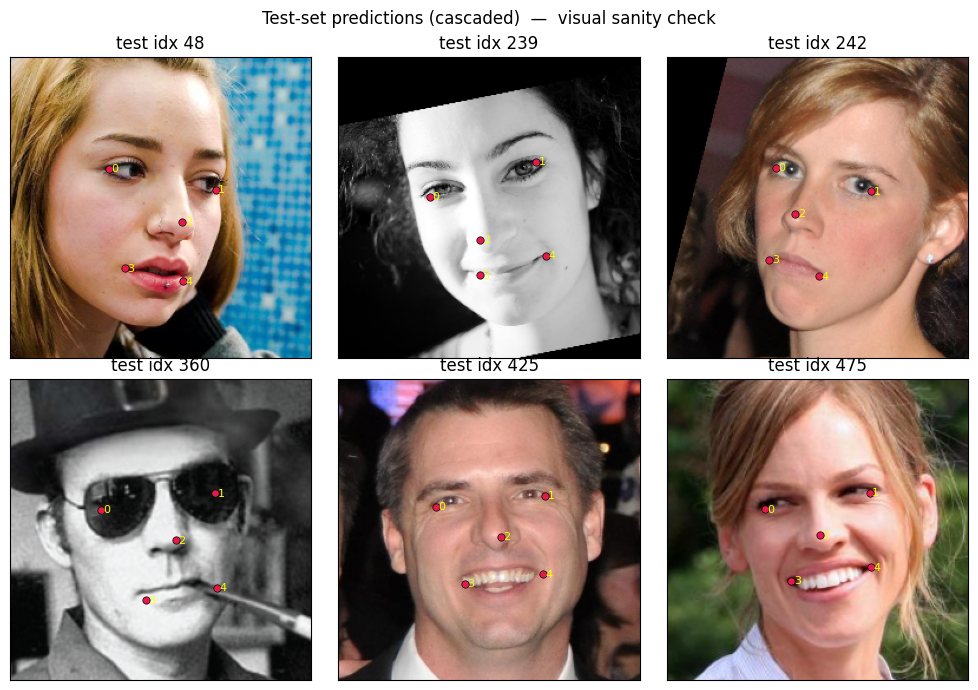

saved /Users/joebaldwin/Desktop/2nd-year/Second-Semester/Introduction to Applied Machine Learning/AMLAssignment/task2_cv/figures/test_predictions_examples.png


In [9]:
rng = np.random.default_rng(SEED)
picks = rng.choice(N_test, size=6, replace=False)
picks.sort()

fig, axes = plt.subplots(2, 3, figsize=(10, 7))
for ax, idx in zip(axes.flat, picks):
    img = test_images[idx]
    if img.ndim == 3:
        if img.shape[-1] == 1:
            ax.imshow(img[..., 0], cmap='gray')
        else:
            ax.imshow(img)
    else:
        ax.imshow(img, cmap='gray')
    p = predictions_orig[idx]
    ax.scatter(p[:, 0], p[:, 1], s=28, c='#e6194B', edgecolors='black', linewidths=0.5)
    for k, (x, y) in enumerate(p):
        ax.text(x + 2, y + 2, str(k), color='yellow', fontsize=8)
    ax.set_title(f'test idx {idx}'); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f'Test-set predictions ({BEST_LABEL})  —  visual sanity check')
fig.tight_layout()
out = FIG_DIR / 'test_predictions_examples.png'
fig.savefig(out, bbox_inches='tight')
plt.show()
print('saved', out)